In [1]:
!apt-get -qq install fonts-nanum
!fc-cache -fv
!rm -rf ~/.cache/matplotlib

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

전체 데이터: 18273
PM 관련 후보군: 277


,보고건수
성분군,
APAP+DPH,16
이부프로펜+DPH,164
나프록센+DPH,25
단일 1세대 항히스타민,72


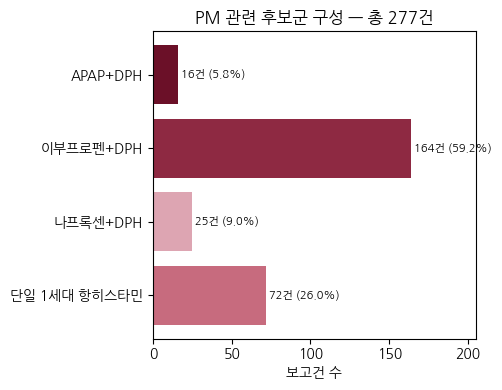

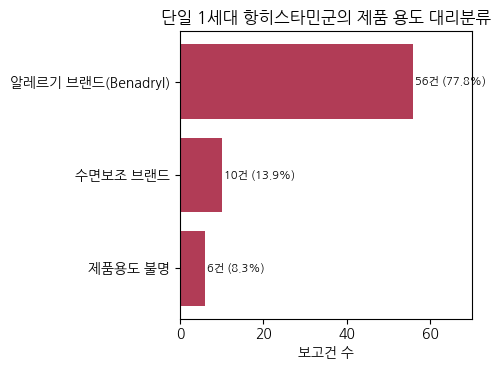

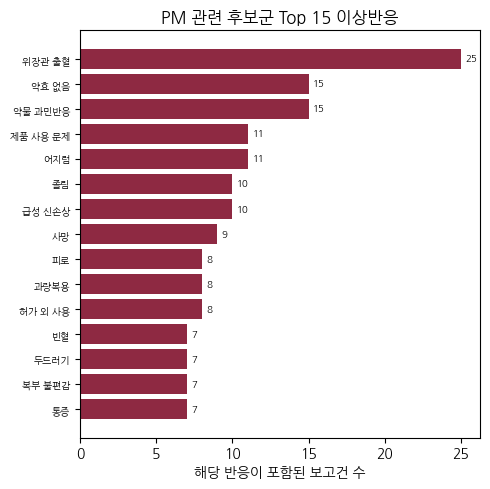

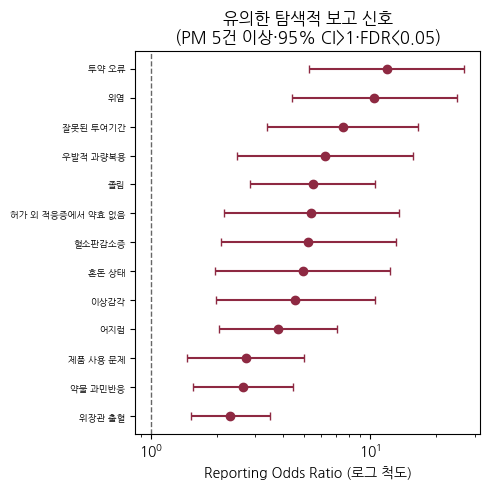

,이상반응,PM 보고건수,ROR,95% CI 하한,95% CI 상한,FDR q-value
250,투약 오류,7,11.937227,5.291940,26.927248,0.000692
52,위염,6,10.463003,4.386388,24.957761,0.002694
245,잘못된 투여기간,7,7.499283,3.401135,16.535435,0.003886
5,우발적 과량복용,5,6.223294,2.468378,15.690218,0.030102
16,졸림,10,5.487198,2.847616,10.573527,0.002104
249,허가 외 적응증에서 약효 없음,5,5.404713,2.154777,13.556354,0.037336
170,혈소판감소증,5,5.232551,2.088409,13.110263,0.039817
17,혼돈 상태,5,4.919063,1.967189,12.300384,0.046879
6,이상감각,6,4.557577,1.975538,10.514357,0.037336
88,어지럼,11,3.794706,2.042500,7.050081,0.010464


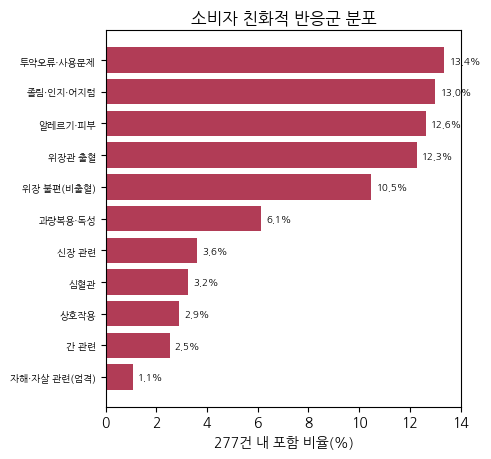

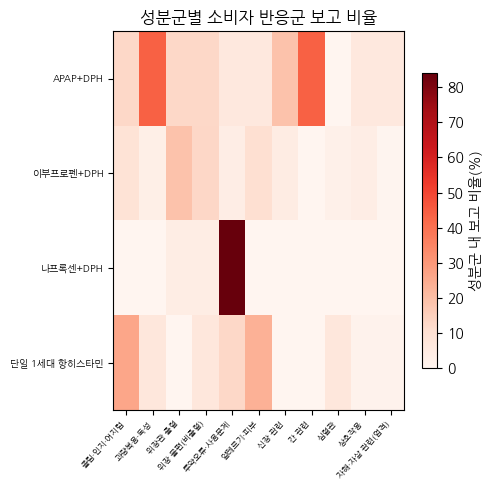

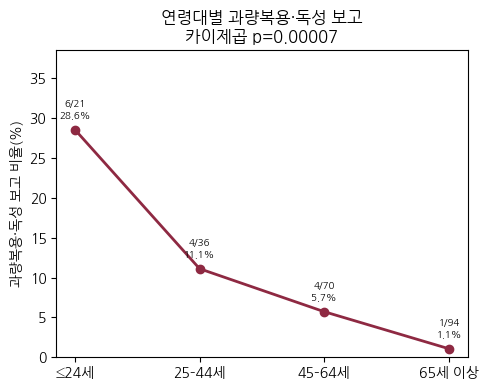

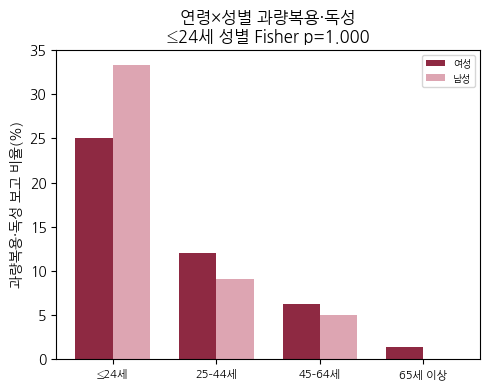

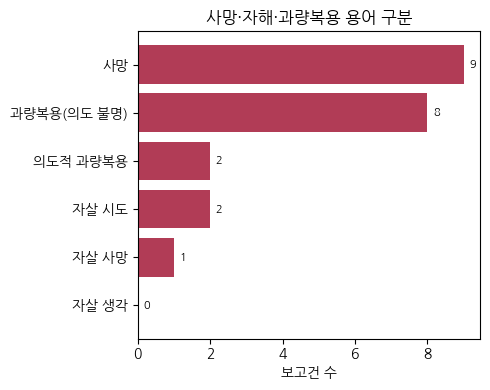

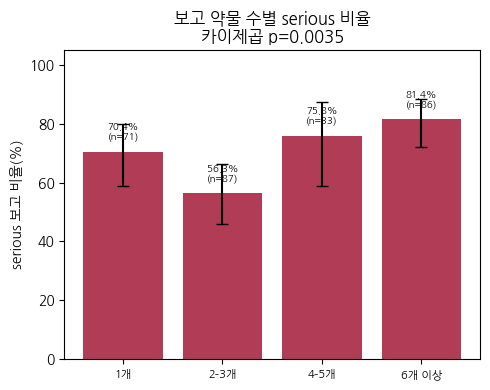

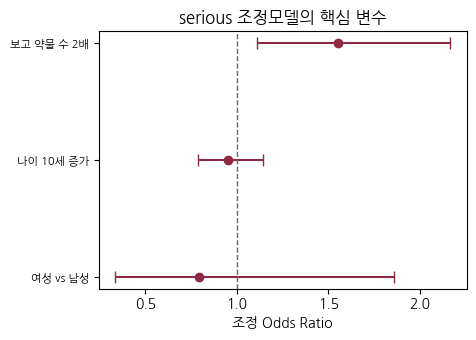

,변수,조정 OR,95% CI 하한,95% CI 상한,p-value,분석 n
0,Intercept,2.727140,0.466856,15.930586,0.265244,217
1,C(성분군)[T.나프록센+DPH],0.029640,0.003384,0.259624,0.001483,217
2,C(성분군)[T.단일 1세대 항히스타민],0.291947,0.055284,1.541729,0.147034,217
3,C(성분군)[T.이부프로펜+DPH],1.593851,0.311028,8.167621,0.576068,217
4,age10,0.948946,0.789515,1.140571,0.576569,217
5,female,0.790145,0.335606,1.860307,0.589797,217
6,log2_num_drugs,1.551049,1.110855,2.165677,0.009959,217



분석 완료
출력 폴더: /content/PM277_최종시각화
연령대×과량복용·독성 p-value: 7.144788604173733e-05
≤24세 성별 Fisher p-value: 1.0
보고 약물 수 구간×serious p-value: 0.0034953327354236147
보고 약물 수 2배 증가 조정 OR: 1.551049246136457
주의: 모든 수치는 FAERS 자발보고 자료의 보고 패턴이며 실제 발생률 또는 인과관계를 의미하지 않습니다.


In [2]:


import os
import math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ------------------------------------------------------------
# 0. 파일 및 출력 경로
# ------------------------------------------------------------
FILE_PATH = Path("/content/FDA_adverse_events_final.csv")
OUTPUT_DIR = Path("/content/PM277_최종시각화")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not FILE_PATH.exists():
    raise FileNotFoundError(
        "FDA_adverse_events_final.csv를 Colab의 /content 폴더에 업로드하세요."
    )

# ------------------------------------------------------------
# 1. 한글 폰트와 시각화 설정
# ------------------------------------------------------------
font_candidates = [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
]
font_path = next((path for path in font_candidates if os.path.exists(path)), None)

if font_path:
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()

plt.rcParams["axes.unicode_minus"] = False

BURGUNDY = "#6B1028"
RED_DARK = "#8E2942"
RED_MAIN = "#B13C56"
RED_MID = "#C76B7E"
RED_LIGHT = "#DDA5B2"
GRAY = "#666666"

def savefig(filename):
    plt.tight_layout()
    plt.show()
    plt.close()

# ------------------------------------------------------------
# 2. 데이터 불러오기 및 PM 관련 후보군 분류
# ------------------------------------------------------------
df = pd.read_csv(FILE_PATH, low_memory=False)

suspect = df["suspect_drug"].fillna("").astype(str).str.upper().str.strip()
brand = df["brand_name"].fillna("").astype(str).str.upper().str.strip()
drug_text = suspect + " " + brand

mask_apap = (
    drug_text.str.contains("DIPHENHYDRAMINE", regex=False, na=False)
    & drug_text.str.contains(r"ACETAMINOPHEN|PARACETAMOL", regex=True, na=False)
)
mask_ibu = (
    drug_text.str.contains("DIPHENHYDRAMINE", regex=False, na=False)
    & drug_text.str.contains("IBUPROFEN", regex=False, na=False)
)
mask_naproxen = (
    drug_text.str.contains("DIPHENHYDRAMINE", regex=False, na=False)
    & drug_text.str.contains("NAPROXEN", regex=False, na=False)
)
mask_single = suspect.isin(
    ["DIPHENHYDRAMINE HYDROCHLORIDE", "DOXYLAMINE SUCCINATE", "DOXYLAMINE"]
)

selected = mask_apap | mask_ibu | mask_naproxen | mask_single
pm = df[selected].copy()

pm["성분군"] = np.select(
    [
        mask_apap.loc[pm.index].to_numpy(),
        mask_ibu.loc[pm.index].to_numpy(),
        mask_naproxen.loc[pm.index].to_numpy(),
        mask_single.loc[pm.index].to_numpy(),
    ],
    [
        "APAP+DPH",
        "이부프로펜+DPH",
        "나프록센+DPH",
        "단일 1세대 항히스타민",
    ],
    default="기타",
)

GROUP_ORDER = [
    "APAP+DPH",
    "이부프로펜+DPH",
    "나프록센+DPH",
    "단일 1세대 항히스타민",
]

print("전체 데이터:", len(df))
print("PM 관련 후보군:", len(pm))
display(pm["성분군"].value_counts().reindex(GROUP_ORDER).to_frame("보고건수"))

# ------------------------------------------------------------
# 3. 공통 전처리
# ------------------------------------------------------------
def split_reactions(value):
    if pd.isna(value):
        return []

    values = [
        item.strip()
        for item in str(value).split(";")
        if item.strip() and item.strip().lower() not in {"unknown", "nan"}
    ]
    return list(dict.fromkeys(values))

pm["reaction_list"] = pm["reactions"].apply(split_reactions)
all_reaction_lists = df["reactions"].apply(split_reactions)

pm["age_num"] = pd.to_numeric(
    pm["patient_age_years"].replace("Unknown", np.nan), errors="coerce"
)
pm["weight_num"] = pd.to_numeric(
    pm["patient_weight_kg"].replace("Unknown", np.nan), errors="coerce"
)
pm["num_drugs_num"] = pd.to_numeric(pm["num_drugs"], errors="coerce")
pm["sex_clean"] = pm["patient_sex"].fillna("Unknown").astype(str)
pm["serious_bool"] = pm["serious"].astype(str).str.lower().eq("yes")

def age_group_4(age):
    if pd.isna(age):
        return "Unknown"
    if age <= 24:
        return "≤24세"
    if age <= 44:
        return "25–44세"
    if age <= 64:
        return "45–64세"
    return "65세 이상"

pm["age_group4"] = pm["age_num"].apply(age_group_4)
AGE_ORDER = ["≤24세", "25–44세", "45–64세", "65세 이상"]

# ------------------------------------------------------------
# 4. 구성과 단일 항히스타민군 내부 분류
# ------------------------------------------------------------
composition = (
    pm["성분군"]
    .value_counts()
    .reindex(GROUP_ORDER)
    .rename_axis("성분군")
    .reset_index(name="보고건수")
)
composition["비율(%)"] = composition["보고건수"] / len(pm) * 100

single = pm[pm["성분군"] == "단일 1세대 항히스타민"].copy()
single_brand = single["brand_name"].fillna("").astype(str).str.upper()

single["제품용도_대리분류"] = np.select(
    [
        single_brand.str.contains(r"UNISOM|ZZZQUIL|SLEEP AID|SLEEP-AID", regex=True),
        single_brand.str.contains("BENADRYL", regex=False),
    ],
    ["수면보조 브랜드", "알레르기 브랜드(Benadryl)"],
    default="제품용도 불명",
)

single_composition = (
    single["제품용도_대리분류"]
    .value_counts()
    .reindex(["알레르기 브랜드(Benadryl)", "수면보조 브랜드", "제품용도 불명"])
    .rename_axis("제품군")
    .reset_index(name="보고건수")
)
single_composition["비율(%)"] = single_composition["보고건수"] / len(single) * 100

# 그래프 1
plt.figure(figsize=(5, 4))
bars = plt.barh(
    composition["성분군"],
    composition["보고건수"],
    color=[BURGUNDY, RED_DARK, RED_LIGHT, RED_MID],
)
plt.gca().invert_yaxis()
plt.title("PM 관련 후보군 구성 — 총 277건", fontweight="bold")
plt.xlabel("보고건 수")
for bar, count, rate in zip(
    bars, composition["보고건수"], composition["비율(%)"]
):
    plt.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count)}건 ({rate:.1f}%)",
        va="center",
        fontsize=8,
    )
plt.xlim(0, composition["보고건수"].max() * 1.25)
savefig("01_PM277_성분군_구성.png")

# 그래프 2
plot = single_composition.sort_values("보고건수")
plt.figure(figsize=(5, 3.8))
bars = plt.barh(plot["제품군"], plot["보고건수"], color=RED_MAIN)
plt.title("단일 1세대 항히스타민군의 제품 용도 대리분류", fontweight="bold")
plt.xlabel("보고건 수")
for bar, count, rate in zip(bars, plot["보고건수"], plot["비율(%)"]):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count)}건 ({rate:.1f}%)",
        va="center",
        fontsize=8,
    )
plt.xlim(0, plot["보고건수"].max() * 1.25)
savefig("02_단일항히스타민_제품용도_분포.png")

# ------------------------------------------------------------
# 5. Top 15 이상반응
# ------------------------------------------------------------
pm_counter = Counter()
for values in pm["reaction_list"]:
    pm_counter.update(set(values))

top15 = pd.DataFrame(
    pm_counter.most_common(15),
    columns=["원문 이상반응", "보고건수"],
)

korean_pt = {
    "Gastrointestinal haemorrhage": "위장관 출혈",
    "Drug hypersensitivity": "약물 과민반응",
    "Drug ineffective": "약효 없음",
    "Dizziness": "어지럼",
    "Product use issue": "제품 사용 문제",
    "Acute kidney injury": "급성 신손상",
    "Somnolence": "졸림",
    "Death": "사망",
    "Overdose": "과량복용",
    "Off label use": "허가 외 사용",
    "Fatigue": "피로",
    "Anaemia": "빈혈",
    "Pain": "통증",
    "Abdominal discomfort": "복부 불편감",
    "Urticaria": "두드러기",
    "Medication error": "투약 오류",
    "Gastritis": "위염",
    "Incorrect drug administration duration": "잘못된 투여기간",
    "Accidental overdose": "우발적 과량복용",
    "Drug ineffective for unapproved indication": "허가 외 적응증에서 약효 없음",
    "Thrombocytopenia": "혈소판감소증",
    "Confusional state": "혼돈 상태",
    "Feeling abnormal": "이상감각",
}

top15["이상반응"] = top15["원문 이상반응"].map(korean_pt).fillna(
    top15["원문 이상반응"]
)
top15["277건 내 비율(%)"] = top15["보고건수"] / len(pm) * 100

plot = top15.sort_values("보고건수")
plt.figure(figsize=(5, 5))
bars = plt.barh(plot["이상반응"], plot["보고건수"], color=RED_DARK)
plt.title("PM 관련 후보군 Top 15 이상반응", fontweight="bold")
plt.xlabel("해당 반응이 포함된 보고건 수")
plt.yticks(fontsize=7)
for bar, count in zip(bars, plot["보고건수"]):
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count)}",
        va="center",
        fontsize=7,
    )
savefig("03_Top15_이상반응.png")

# ------------------------------------------------------------
# 6. ROR·95% CI·FDR
# ------------------------------------------------------------
all_sets = [set(values) for values in all_reaction_lists]
pm_indices = set(pm.index.tolist())
n_pm = len(pm)
n_other = len(df) - n_pm

ror_rows = []

for term, count in pm_counter.items():
    a = int(count)
    c = int(
        sum(
            term in all_sets[index]
            for index in range(len(df))
            if index not in pm_indices
        )
    )

    b = n_pm - a
    d = n_other - c

    aa, bb, cc, dd = map(float, [a, b, c, d])
    if min(aa, bb, cc, dd) == 0:
        aa += 0.5
        bb += 0.5
        cc += 0.5
        dd += 0.5

    ror = (aa * dd) / (bb * cc)
    standard_error = math.sqrt(1 / aa + 1 / bb + 1 / cc + 1 / dd)
    lower = math.exp(math.log(ror) - 1.96 * standard_error)
    upper = math.exp(math.log(ror) + 1.96 * standard_error)
    p_value = fisher_exact([[a, b], [c, d]])[1]

    ror_rows.append(
        {
            "원문 이상반응": term,
            "PM 보고건수": a,
            "비교군 보고건수": c,
            "ROR": ror,
            "95% CI 하한": lower,
            "95% CI 상한": upper,
            "p-value": p_value,
        }
    )

ror_results = pd.DataFrame(ror_rows)
ror_results["FDR q-value"] = multipletests(
    ror_results["p-value"], method="fdr_bh"
)[1]
ror_results["이상반응"] = ror_results["원문 이상반응"].map(korean_pt).fillna(
    ror_results["원문 이상반응"]
)

ror_signals = ror_results[
    (ror_results["PM 보고건수"] >= 5)
    & (ror_results["ROR"] > 1)
    & (ror_results["95% CI 하한"] > 1)
    & (ror_results["FDR q-value"] < 0.05)
].sort_values("ROR", ascending=False)

plot = ror_signals.sort_values("ROR")
y = np.arange(len(plot))

plt.figure(figsize=(5, 5))
plt.errorbar(
    plot["ROR"],
    y,
    xerr=[
        plot["ROR"] - plot["95% CI 하한"],
        plot["95% CI 상한"] - plot["ROR"],
    ],
    fmt="o",
    capsize=3,
    color=RED_DARK,
)
plt.axvline(1, linestyle="--", linewidth=1, color=GRAY)
plt.yticks(y, plot["이상반응"], fontsize=6.7)
plt.xscale("log")
plt.xlabel("Reporting Odds Ratio (로그 척도)")
plt.title(
    "유의한 탐색적 보고 신호\n(PM 5건 이상·95% CI>1·FDR<0.05)",
    fontweight="bold",
)
savefig("04_ROR_유의신호_포레스트.png")

display(
    ror_signals[
        ["이상반응", "PM 보고건수", "ROR", "95% CI 하한", "95% CI 상한", "FDR q-value"]
    ]
)

# ------------------------------------------------------------
# 7. 소비자 친화적 반응군과 성분군 히트맵
# ------------------------------------------------------------
reaction_groups = {
    "졸림·인지·어지럼": [
        "Somnolence", "Dizziness", "Confusional state", "Fatigue",
        "Attention disturbance", "Memory impairment", "Delirium",
        "Fall", "Balance disorder", "Loss of consciousness",
        "Sluggishness", "Incoherent",
    ],
    "과량복용·독성": [
        "Overdose", "Intentional overdose", "Accidental overdose",
        "Toxicity to various agents", "Drug toxicity",
    ],
    "위장관 출혈": [
        "Gastrointestinal haemorrhage", "Melaena", "Haematemesis",
        "Haematochezia", "Rectal haemorrhage",
        "Gastric ulcer haemorrhage", "Gastritis haemorrhagic",
    ],
    "위장 불편(비출혈)": [
        "Abdominal pain", "Abdominal discomfort", "Nausea", "Vomiting",
        "Dyspepsia", "Diarrhoea", "Constipation", "Gastritis",
    ],
    "투약오류·사용문제": [
        "Medication error", "Incorrect drug administration duration",
        "Product use issue", "Wrong drug administered", "Off label use",
        "Incorrect dose administered",
        "Drug ineffective for unapproved indication",
    ],
    "알레르기·피부": [
        "Drug hypersensitivity", "Urticaria", "Rash",
        "Anaphylactic reaction", "Anaphylactoid reaction",
        "Angioedema", "Pruritus", "Injection site urticaria",
    ],
    "신장 관련": [
        "Acute kidney injury", "Renal failure",
        "Renal impairment", "Kidney injury",
    ],
    "간 관련": [
        "Acute hepatic failure", "Hepatic failure", "Liver injury",
        "Drug-induced liver injury", "Hepatotoxicity",
        "Transaminases increased",
    ],
    "심혈관": [
        "Hypertension", "Hypotension", "Tachycardia", "Bradycardia",
        "Palpitations", "Myocardial infarction", "Cardiac arrest",
        "Heart rate increased",
    ],
    "상호작용": ["Drug interaction", "Alcohol interaction"],
    "자해·자살 관련(엄격)": [
        "Completed suicide", "Suicide attempt", "Suicidal ideation",
    ],
}

def has_any_term(reaction_list, terms):
    return any(value in terms for value in reaction_list)

for group_name, terms in reaction_groups.items():
    pm[group_name] = pm["reaction_list"].apply(
        lambda values, current_terms=terms: has_any_term(values, current_terms)
    )

reaction_group_summary = pd.DataFrame(
    {
        "반응군": list(reaction_groups.keys()),
        "보고건수": [int(pm[name].sum()) for name in reaction_groups],
    }
)
reaction_group_summary["277건 내 비율(%)"] = (
    reaction_group_summary["보고건수"] / len(pm) * 100
)
reaction_group_summary = reaction_group_summary.sort_values(
    "277건 내 비율(%)", ascending=False
)

plot = reaction_group_summary.sort_values("277건 내 비율(%)")
plt.figure(figsize=(5, 4.7))
bars = plt.barh(
    plot["반응군"], plot["277건 내 비율(%)"], color=RED_MAIN
)
plt.title("소비자 친화적 반응군 분포", fontweight="bold")
plt.xlabel("277건 내 포함 비율(%)")
plt.yticks(fontsize=7)
for bar, rate in zip(bars, plot["277건 내 비율(%)"]):
    plt.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1f}%",
        va="center",
        fontsize=7,
    )
savefig("05_소비자_반응군_분포.png")

group_heatmap = (
    pm.groupby("성분군")[list(reaction_groups.keys())]
    .mean()
    .mul(100)
    .reindex(GROUP_ORDER)
)

plt.figure(figsize=(5, 5))
plt.imshow(group_heatmap.values, cmap="Reds", aspect="auto")
plt.colorbar(label="성분군 내 보고 비율(%)", shrink=0.78)
plt.xticks(
    np.arange(len(group_heatmap.columns)),
    group_heatmap.columns,
    rotation=48,
    ha="right",
    fontsize=6,
)
plt.yticks(
    np.arange(len(group_heatmap.index)),
    group_heatmap.index,
    fontsize=7,
)
plt.title("성분군별 소비자 반응군 보고 비율", fontweight="bold")
savefig("06_성분군_반응군_히트맵.png")

# ------------------------------------------------------------
# 8. 연령 및 성별
# ------------------------------------------------------------
pm["과량복용·독성 여부"] = pm["과량복용·독성"]

age_known = pm[pm["age_group4"].isin(AGE_ORDER)].copy()

age_overdose = (
    age_known.groupby("age_group4")["과량복용·독성 여부"]
    .agg(["sum", "count"])
    .reindex(AGE_ORDER)
    .reset_index()
)
age_overdose["비율(%)"] = age_overdose["sum"] / age_overdose["count"] * 100

age_table = pd.crosstab(
    age_known["age_group4"], age_known["과량복용·독성 여부"]
).reindex(AGE_ORDER, fill_value=0)
age_chi2, age_p, age_dof, age_expected = chi2_contingency(age_table)

plt.figure(figsize=(5, 4))
plt.plot(
    age_overdose["age_group4"],
    age_overdose["비율(%)"],
    marker="o",
    linewidth=2,
    color=RED_DARK,
)
for age, rate, events, total in zip(
    age_overdose["age_group4"],
    age_overdose["비율(%)"],
    age_overdose["sum"],
    age_overdose["count"],
):
    plt.text(
        age,
        rate + 1.5,
        f"{int(events)}/{int(total)}\n{rate:.1f}%",
        ha="center",
        fontsize=7,
    )
plt.ylabel("과량복용·독성 보고 비율(%)")
plt.title(
    f"연령대별 과량복용·독성 보고\n카이제곱 p={age_p:.5f}",
    fontweight="bold",
)
plt.ylim(0, age_overdose["비율(%)"].max() + 10)
savefig("07_연령대_과량복용독성.png")

age_sex = pm[
    pm["age_group4"].isin(AGE_ORDER)
    & pm["sex_clean"].isin(["Female", "Male"])
].copy()

age_sex_summary = (
    age_sex.groupby(["age_group4", "sex_clean"])["과량복용·독성 여부"]
    .agg(["sum", "count"])
    .reset_index()
)
age_sex_summary["비율(%)"] = (
    age_sex_summary["sum"] / age_sex_summary["count"] * 100
)

young = age_sex[age_sex["age_group4"] == "≤24세"]
young_table = pd.crosstab(
    young["sex_clean"], young["과량복용·독성 여부"]
).reindex(index=["Female", "Male"], columns=[False, True], fill_value=0)
young_or, young_sex_p = fisher_exact(young_table.to_numpy())

pivot_rate = age_sex_summary.pivot(
    index="age_group4", columns="sex_clean", values="비율(%)"
).reindex(AGE_ORDER)

x = np.arange(len(AGE_ORDER))
width = 0.36

plt.figure(figsize=(5, 4))
plt.bar(
    x - width / 2,
    pivot_rate.get("Female", pd.Series(index=AGE_ORDER, data=np.nan)),
    width,
    label="여성",
    color=RED_DARK,
)
plt.bar(
    x + width / 2,
    pivot_rate.get("Male", pd.Series(index=AGE_ORDER, data=np.nan)),
    width,
    label="남성",
    color=RED_LIGHT,
)
plt.xticks(x, AGE_ORDER, fontsize=8)
plt.ylabel("과량복용·독성 보고 비율(%)")
plt.title(
    f"연령×성별 과량복용·독성\n≤24세 성별 Fisher p={young_sex_p:.3f}",
    fontweight="bold",
)
plt.legend(fontsize=7)
savefig("08_연령성별_과량복용독성.png")

# ------------------------------------------------------------
# 9. 사망·자해·과량복용 용어 분리
# ------------------------------------------------------------
critical_terms = [
    "Death",
    "Completed suicide",
    "Suicide attempt",
    "Suicidal ideation",
    "Intentional overdose",
    "Overdose",
]

critical_korean = {
    "Death": "사망",
    "Completed suicide": "자살 사망",
    "Suicide attempt": "자살 시도",
    "Suicidal ideation": "자살 생각",
    "Intentional overdose": "의도적 과량복용",
    "Overdose": "과량복용(의도 불명)",
}

critical_summary = pd.DataFrame(
    {
        "원문 용어": critical_terms,
        "표시명": [critical_korean[term] for term in critical_terms],
        "보고건수": [pm_counter.get(term, 0) for term in critical_terms],
    }
)

plot = critical_summary.sort_values("보고건수")
plt.figure(figsize=(5, 4))
bars = plt.barh(plot["표시명"], plot["보고건수"], color=RED_MAIN)
plt.title("사망·자해·과량복용 용어 구분", fontweight="bold")
plt.xlabel("보고건 수")
for bar, count in zip(bars, plot["보고건수"]):
    plt.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count)}",
        va="center",
        fontsize=8,
    )
savefig("09_사망_자해_과량용어_구분.png")

# ------------------------------------------------------------
# 10. 보고 약물 수와 serious
# ------------------------------------------------------------
pm["보고 약물 수 구간"] = pd.cut(
    pm["num_drugs_num"],
    bins=[0, 1, 3, 5, np.inf],
    labels=["1개", "2–3개", "4–5개", "6개 이상"],
    right=True,
)
DRUG_COUNT_ORDER = ["1개", "2–3개", "4–5개", "6개 이상"]

drug_count_summary = (
    pm.groupby("보고 약물 수 구간", observed=False)["serious_bool"]
    .agg(["sum", "count"])
    .reindex(DRUG_COUNT_ORDER)
    .reset_index()
)
drug_count_summary["serious 비율(%)"] = (
    drug_count_summary["sum"] / drug_count_summary["count"] * 100
)

confidence_intervals = drug_count_summary.apply(
    lambda row: proportion_confint(
        count=int(row["sum"]),
        nobs=int(row["count"]),
        alpha=0.05,
        method="wilson",
    ),
    axis=1,
)
drug_count_summary["95% CI 하한(%)"] = [
    interval[0] * 100 for interval in confidence_intervals
]
drug_count_summary["95% CI 상한(%)"] = [
    interval[1] * 100 for interval in confidence_intervals
]

drug_count_table = pd.crosstab(
    pm["보고 약물 수 구간"], pm["serious_bool"]
).reindex(DRUG_COUNT_ORDER, fill_value=0)
drug_chi2, drug_p, drug_dof, drug_expected = chi2_contingency(
    drug_count_table
)

x = np.arange(len(drug_count_summary))
rates = drug_count_summary["serious 비율(%)"].to_numpy()
lower_errors = rates - drug_count_summary["95% CI 하한(%)"].to_numpy()
upper_errors = drug_count_summary["95% CI 상한(%)"].to_numpy() - rates

plt.figure(figsize=(5, 4))
bars = plt.bar(
    x,
    rates,
    color=RED_MAIN,
    yerr=[lower_errors, upper_errors],
    capsize=4,
)
plt.xticks(x, drug_count_summary["보고 약물 수 구간"], fontsize=8)
plt.ylabel("serious 보고 비율(%)")
plt.title(
    f"보고 약물 수별 serious 비율\n카이제곱 p={drug_p:.4f}",
    fontweight="bold",
)
for bar, rate, total in zip(
    bars,
    drug_count_summary["serious 비율(%)"],
    drug_count_summary["count"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 4,
        f"{rate:.1f}%\n(n={int(total)})",
        ha="center",
        fontsize=7,
    )
plt.ylim(0, 105)
savefig("10_보고약물수_serious.png")

# 조정 모델
model_data = pm[
    pm["age_num"].notna()
    & pm["sex_clean"].isin(["Female", "Male"])
    & pm["num_drugs_num"].notna()
    & (pm["num_drugs_num"] > 0)
].copy()

model_data["age10"] = (
    model_data["age_num"] - model_data["age_num"].mean()
) / 10
model_data["female"] = (
    model_data["sex_clean"] == "Female"
).astype(int)
model_data["log2_num_drugs"] = np.log2(model_data["num_drugs_num"])
model_data["serious_int"] = model_data["serious_bool"].astype(int)

model = smf.glm(
    "serious_int ~ age10 + female + log2_num_drugs + C(성분군)",
    data=model_data,
    family=sm.families.Binomial(),
).fit()

confidence = model.conf_int()
model_results = pd.DataFrame(
    {
        "변수": model.params.index,
        "조정 OR": np.exp(model.params.values),
        "95% CI 하한": np.exp(confidence.iloc[:, 0].values),
        "95% CI 상한": np.exp(confidence.iloc[:, 1].values),
        "p-value": model.pvalues.values,
        "분석 n": int(model.nobs),
    }
)

adjusted_plot = pd.DataFrame(
    {
        "변수": ["나이 10세 증가", "여성 vs 남성", "보고 약물 수 2배"],
        "OR": [
            model_results.loc[model_results["변수"] == "age10", "조정 OR"].iloc[0],
            model_results.loc[model_results["변수"] == "female", "조정 OR"].iloc[0],
            model_results.loc[
                model_results["변수"] == "log2_num_drugs", "조정 OR"
            ].iloc[0],
        ],
        "하한": [
            model_results.loc[
                model_results["변수"] == "age10", "95% CI 하한"
            ].iloc[0],
            model_results.loc[
                model_results["변수"] == "female", "95% CI 하한"
            ].iloc[0],
            model_results.loc[
                model_results["변수"] == "log2_num_drugs", "95% CI 하한"
            ].iloc[0],
        ],
        "상한": [
            model_results.loc[
                model_results["변수"] == "age10", "95% CI 상한"
            ].iloc[0],
            model_results.loc[
                model_results["변수"] == "female", "95% CI 상한"
            ].iloc[0],
            model_results.loc[
                model_results["변수"] == "log2_num_drugs", "95% CI 상한"
            ].iloc[0],
        ],
    }
).sort_values("OR")

y = np.arange(len(adjusted_plot))
plt.figure(figsize=(5, 3.5))
plt.errorbar(
    adjusted_plot["OR"],
    y,
    xerr=[
        adjusted_plot["OR"] - adjusted_plot["하한"],
        adjusted_plot["상한"] - adjusted_plot["OR"],
    ],
    fmt="o",
    capsize=4,
    color=RED_DARK,
)
plt.axvline(1, linestyle="--", linewidth=1, color=GRAY)
plt.yticks(y, adjusted_plot["변수"], fontsize=8)
plt.xlabel("조정 Odds Ratio")
plt.title("serious 조정모델의 핵심 변수", fontweight="bold")
savefig("11_serious_조정OR.png")

display(model_results)

# ------------------------------------------------------------
# 11. 결과 저장
# ------------------------------------------------------------
tables = {
    "01_성분군_구성.csv": composition,
    "02_단일항히스타민_제품용도.csv": single_composition,
    "03_Top15_이상반응.csv": top15,
    "04_ROR_전체결과.csv": ror_results.sort_values("FDR q-value"),
    "05_ROR_유의신호_5건이상.csv": ror_signals,
    "06_소비자_반응군.csv": reaction_group_summary,
    "07_성분군_반응군_비율.csv": group_heatmap.reset_index(),
    "08_연령대_과량복용독성.csv": age_overdose,
    "09_연령성별_과량복용독성.csv": age_sex_summary,
    "10_사망자해과량_용어구분.csv": critical_summary,
    "11_보고약물수_serious.csv": drug_count_summary,
    "12_조정로지스틱회귀.csv": model_results,
}

for filename, table in tables.items():
    table.to_csv(OUTPUT_DIR / filename, index=False, encoding="utf-8-sig")

print("\n분석 완료")
print("출력 폴더:", OUTPUT_DIR)
print("연령대×과량복용·독성 p-value:", age_p)
print("≤24세 성별 Fisher p-value:", young_sex_p)
print("보고 약물 수 구간×serious p-value:", drug_p)
print(
    "보고 약물 수 2배 증가 조정 OR:",
    model_results.loc[
        model_results["변수"] == "log2_num_drugs", "조정 OR"
    ].iloc[0],
)
print(
    "주의: 모든 수치는 FAERS 자발보고 자료의 보고 패턴이며 "
    "실제 발생률 또는 인과관계를 의미하지 않습니다."
)

로드: (18273, 28)
PM류: 324 건
sub
A      16
B1    164
B2     25
C     119
Name: count, dtype: int64


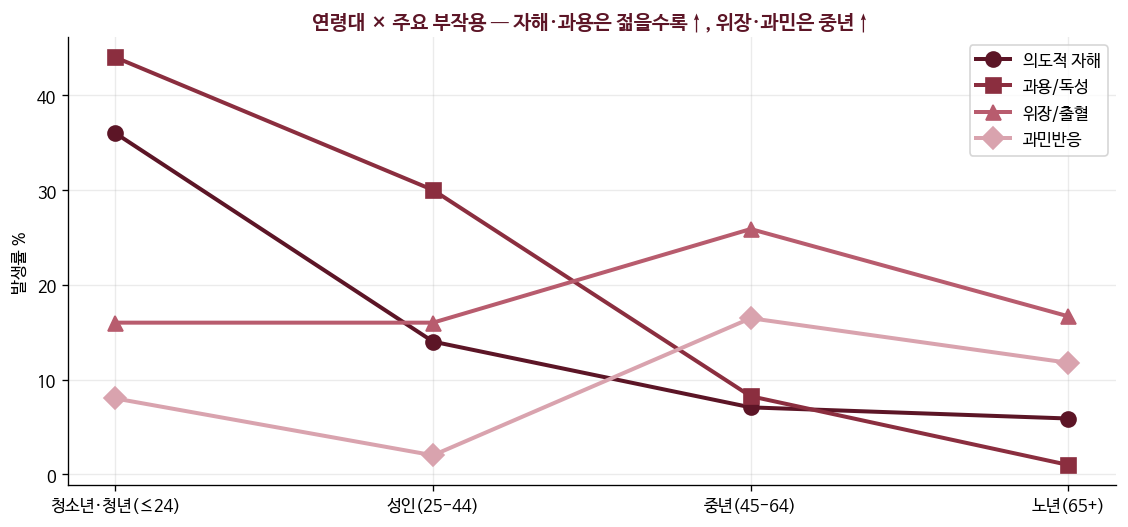

연령대별 발생률(%) + 카이제곱 검정
 [의도적 자해] p=0.0001  청소년·청년 9/25(36%)  성인 7/50(14%)  중년 6/85(7%)  노년 6/102(6%)
 [과용/독성] p=0.0000  청소년·청년 11/25(44%)  성인 15/50(30%)  중년 7/85(8%)  노년 1/102(1%)
 [위장/출혈] p=0.3453  청소년·청년 4/25(16%)  성인 8/50(16%)  중년 22/85(26%)  노년 17/102(17%)
 [과민반응] p=0.0723  청소년·청년 2/25(8%)  성인 1/50(2%)  중년 14/85(16%)  노년 12/102(12%)
[자해(좁은정의)] 연령 1세↑ OR=0.964 (p=0.0002247) | Spearman rho=-0.232
[자해+과용(넓은정의)] 연령 1세↑ OR=0.946 (p=2.393e-09) | Spearman rho=-0.399
[과용/독성] 연령 1세↑ OR=0.939 (p=1.12e-08) | Spearman rho=-0.393


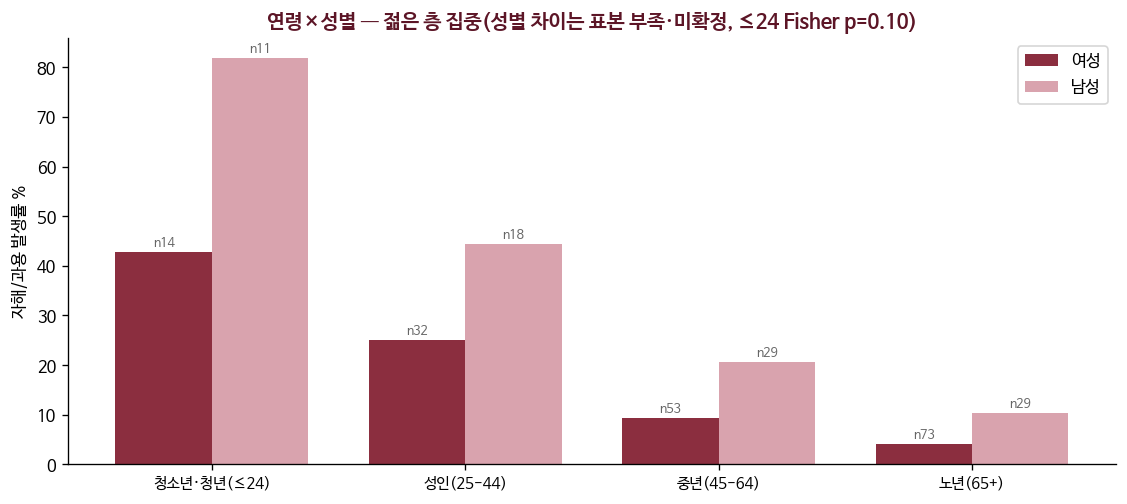

sex             F     M
ag                     
청소년·청년(≤24)  42.9  81.8
성인(25-44)    25.0  44.4
중년(45-64)     9.4  20.7
노년(65+)       4.1  10.3
(표본수)
sex           F   M
ag                 
청소년·청년(≤24)  14  11
성인(25-44)    32  18
중년(45-64)    53  29
노년(65+)      73  29


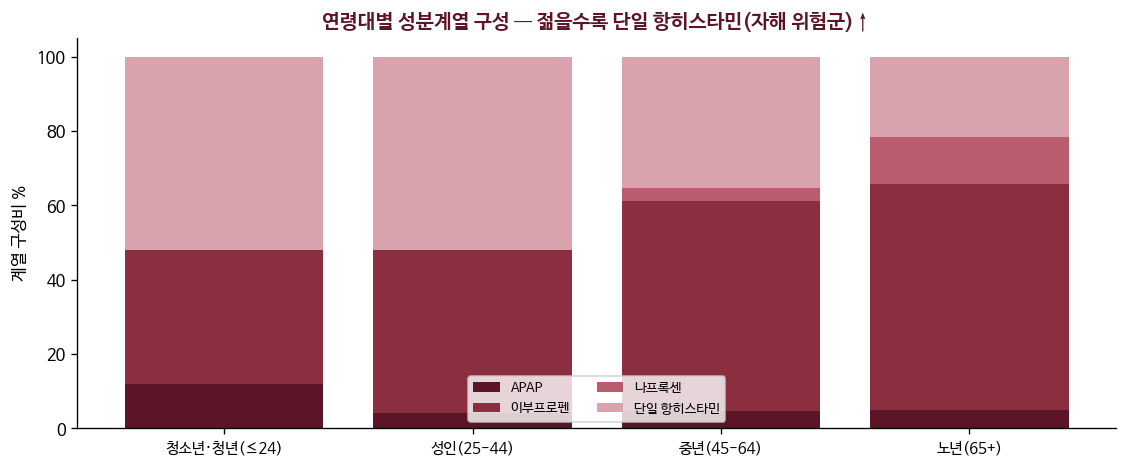

연령대별 계열 구성비(%)
sub             A    B1    B2     C
ag                                 
청소년·청년(≤24)  12.0  36.0   0.0  52.0
성인(25-44)     4.0  44.0   0.0  52.0
중년(45-64)     4.7  56.5   3.5  35.3
노년(65+)       4.9  60.8  12.7  21.6


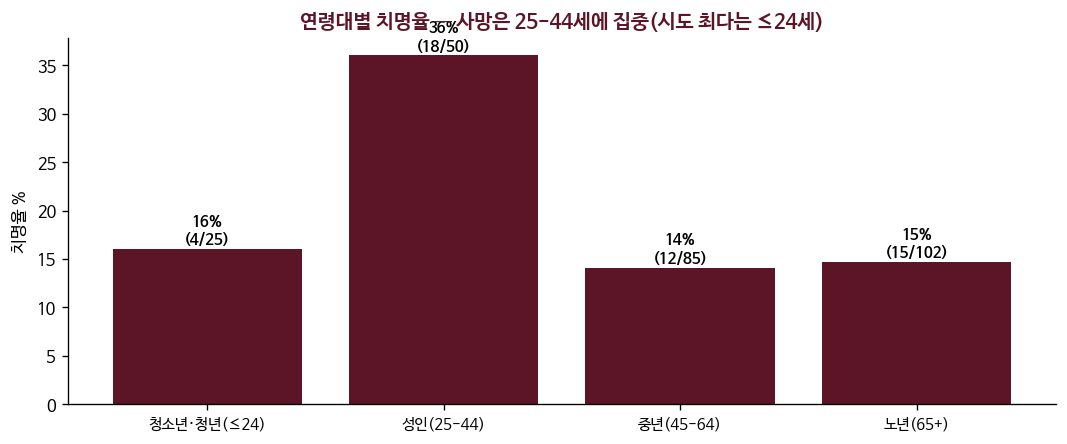

연령대별 치명율:
ag
청소년·청년(≤24)    16.0
성인(25-44)      36.0
중년(45-64)      14.1
노년(65+)        14.7
        연령대           주된 위험                           핵심 메시지
청소년·청년(≤24) 의도적 과용·자해(정신건강)      순한 수면제도 과량은 위험 — 위기 시 상담 연결
  성인(25-44)    과용→사망 치명성 최고       과용이 사망으로 이어질 위험 최고 — 의존 주의
  중년(45-64)   위장출혈·과민반응(신체) 이부프로펜 복합제 위장출혈 주의(위장약·항응고제 병용 시)
    노년(65+)    항콜린·낙상, 상호작용    1세대 항히스타민은 노인 회피 권장 — 상호작용 주의

※ 주의: 자발적 보고 기반이라 "발생률"이 아닌 "보고 패턴". 자해 안내에는 위기상담 정보 병기 권장.


In [3]:

!pip -q install statsmodels >/dev/null 2>&1
!apt -qq install fonts-nanum -y >/dev/null 2>&1

import pandas as pd, numpy as np, warnings, glob
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
from scipy import stats
import statsmodels.formula.api as smf
warnings.filterwarnings('ignore')

for f in glob.glob('/usr/share/fonts/truetype/nanum/*.ttf'):
    fm.fontManager.addfont(f)
plt.rc('font', family='NanumBarunGothic')
plt.rc('axes', unicode_minus=False)
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})

BURG = ['#F2E4E7','#D9A3AE','#B85C6E','#8B2E3F','#5C1526']
MAIN, ALT, GREY = '#8B2E3F', '#D9A3AE', '#9E9E9E'

PATH = '/content/FDA_adverse_events_final.csv'
df = pd.read_csv(PATH, low_memory=False)
print('로드:', df.shape)


# %% [1] 정제 + PM류 4계열 태깅 + 표준 연령대 -----------------------
df['serious_bin'] = (df['serious'].astype(str).str.strip().str.lower()=='yes').astype(int)
df['age']    = pd.to_numeric(df['patient_age_years'], errors='coerce')
df['sex']    = df['patient_sex'].astype(str).str.upper().str[0].map({'M':'M','F':'F'})
df['ndrugs'] = pd.to_numeric(df['num_drugs'], errors='coerce')
df['fatal']  = df['is_fatal'].astype(bool).astype(int)

def tag_pm(df):
    t = df['brand_name'].fillna('').str.upper() + ' ; ' + df['suspect_drug'].fillna('').str.upper()
    ibu  = t.str.contains('IBUPROFEN', na=False)
    nap  = t.str.contains('NAPROXEN', na=False)
    apap = t.str.contains(r'ACETAMINOPHEN|PARACETAMOL', regex=True, na=False)
    sed  = t.str.contains(r'DIPHENHYDRAMINE|DOXYLAMINE', regex=True, na=False)
    sleep= t.str.contains(r'\bPM\b|SLEEP|UNISOM|ZZZQUIL|SOMINEX|NYTOL|NIGHT ?TIME|NIGHTTIME|NIGHTIME', regex=True, na=False)
    excl = t.str.contains(r'PYRIDOXINE|DICLEGIS|DEXTROMETHORPHAN|NYQUIL|ROBITUSSIN|GUAIFENESIN', regex=True, na=False)
    cls = pd.Series(index=df.index, dtype=object)
    cls[sed & ibu & ~excl] = 'B1'
    cls[cls.isna() & sed & nap & ~excl] = 'B2'
    cls[cls.isna() & sed & apap & ~excl] = 'A'
    cls[cls.isna() & sed & ~apap & ~ibu & ~nap & sleep & ~excl] = 'C'
    return cls

df['sub'] = tag_pm(df)
df['is_pm'] = df['sub'].notna().astype(int)

# 표준 역학 구간
AG = ['청소년·청년(≤24)','성인(25-44)','중년(45-64)','노년(65+)']
df['ag'] = pd.cut(df['age'], [0,24,44,64,200], labels=AG)

pm = df[df['is_pm']==1].copy()
print('PM류:', len(pm), '건')
print(pm['sub'].value_counts().reindex(['A','B1','B2','C']))


# %% [2] 부작용 카테고리 플래그 생성 -------------------------------
# 자해·과용은 좁은/넓은 정의를 모두 만들어 둔다 (정의에 따라 결과가 달라지므로)
rxU = pm['reactions'].fillna('').str.upper()
pm['자해_좁은'] = rxU.str.contains(r'SUICID|SELF.?INJURIOUS|INTENTIONAL OVERDOSE|INTENTIONAL PRODUCT MISUSE', regex=True, na=False).astype(int)
pm['자해_넓은'] = rxU.str.contains(r'SUICID|SELF.?INJURIOUS|INTENTIONAL OVERDOSE|INTENTIONAL PRODUCT MISUSE|\bOVERDOSE\b|TOXICITY|POISONING', regex=True, na=False).astype(int)
pm['과용독성']  = rxU.str.contains(r'\bOVERDOSE\b|TOXICITY|POISONING', regex=True, na=False).astype(int)
pm['위장출혈']  = rxU.str.contains(r'GASTROINTESTINAL HAEMORRHAGE|ABDOMINAL|DYSPEPSIA|GASTRIC|NAUSEA|VOMITING|DIARRHOEA', regex=True, na=False).astype(int)
pm['과민반응']  = rxU.str.contains(r'HYPERSENSITIVITY|URTICARIA|ANGIOEDEMA|ANAPHYLA|RASH|PRURITUS', regex=True, na=False).astype(int)
pm['항콜린']    = rxU.str.contains(r'DRY MOUTH|URINARY RETENTION|CONSTIPATION|VISION BLURRED|DELIRIUM|HALLUCINAT|CONFUSIONAL', regex=True, na=False).astype(int)


# %% [3] 연령대 × 주요 부작용 추세 (그래프 + 카이제곱) --------------
show = {'의도적 자해':'자해_좁은','과용/독성':'과용독성','위장/출혈':'위장출혈','과민반응':'과민반응'}
marker = ['o','s','^','D']; colors = [BURG[4],MAIN,BURG[2],BURG[1]]
fig, ax = plt.subplots(figsize=(9.5,4.5))
for (lab,col0),mk,c in zip(show.items(), marker, colors):
    r = pm.dropna(subset=['ag']).groupby('ag')[col0].mean().reindex(AG)*100
    ax.plot(AG, r.values, marker=mk, ms=9, lw=2.4, label=lab, color=c)
ax.set_ylabel('발생률 %'); ax.legend(); ax.grid(alpha=.25)
ax.set_title('연령대 × 주요 부작용 — 자해·과용은 젊을수록↑, 위장·과민은 중년↑', fontweight='bold', color=BURG[4])
plt.tight_layout(); plt.show()

print('연령대별 발생률(%) + 카이제곱 검정')
for lab,col0 in show.items():
    rate = pm.dropna(subset=['ag']).groupby('ag')[col0].agg(['sum','size','mean'])
    p = stats.chi2_contingency(pd.crosstab(pm['ag'], pm[col0]))[1]
    line = '  '.join(f'{a.split("(")[0]} {int(r["sum"])}/{int(r["size"])}({r["mean"]*100:.0f}%)' for a,r in rate.iterrows())
    print(f' [{lab}] p={p:.4f}  {line}')


# %% [4] 연령 연속변수 회귀 (구간 임의성 배제 근거) -----------------
# 구간을 나누지 않고 나이를 연속으로 봐도 유의한지 = 결론의 강건성 확인
m = pm.dropna(subset=['age'])
for col0, lab in [('자해_좁은','자해(좁은정의)'),('자해_넓은','자해+과용(넓은정의)'),('과용독성','과용/독성')]:
    fit = smf.logit(f'{col0} ~ age', data=m).fit(disp=0)
    rho, prho = stats.spearmanr(m['age'], m[col0])
    print(f'[{lab}] 연령 1세↑ OR={np.exp(fit.params["age"]):.3f} (p={fit.pvalues["age"]:.4g}) | Spearman rho={rho:.3f}')


# %% [5] 연령 × 성별 (성별 차이는 표본 부족 → 미확정) ---------------
pm['harm'] = pm['자해_넓은']
piv  = pm.dropna(subset=['ag','sex']).pivot_table(index='ag', columns='sex', values='harm', aggfunc='mean').reindex(AG)*100
pivn = pm.dropna(subset=['ag','sex']).pivot_table(index='ag', columns='sex', values='harm', aggfunc='size').reindex(AG)
x = np.arange(4); w = .38
fig, ax = plt.subplots(figsize=(9.5,4.3))
ax.bar(x-w/2, piv['F'], w, label='여성', color=MAIN)
ax.bar(x+w/2, piv['M'], w, label='남성', color=BURG[1])
for i in range(4):
    if not np.isnan(piv['F'].values[i]): ax.text(i-w/2, piv['F'].values[i]+1, f"n{int(pivn['F'].values[i])}", ha='center', fontsize=7.5, color='#666')
    if not np.isnan(piv['M'].values[i]): ax.text(i+w/2, piv['M'].values[i]+1, f"n{int(pivn['M'].values[i])}", ha='center', fontsize=7.5, color='#666')
ax.set_xticks(x); ax.set_xticklabels(AG, fontsize=9); ax.set_ylabel('자해/과용 발생률 %'); ax.legend()
# ≤24 성별 Fisher 검정
sub24 = pm[pm['ag']==AG[0]].dropna(subset=['sex'])
pf = stats.fisher_exact(pd.crosstab(sub24['sex'], sub24['harm']))[1]
ax.set_title(f'연령×성별 — 젊은 층 집중(성별 차이는 표본 부족·미확정, ≤24 Fisher p={pf:.2f})', fontweight='bold', color=BURG[4])
plt.tight_layout(); plt.show()
print(piv.round(1).to_string()); print('(표본수)'); print(pivn.to_string())


# %% [6] 연령대별 성분계열 구성 (왜 젊을수록 위험한가) --------------
comp = pm.dropna(subset=['ag']).groupby('ag')['sub'].value_counts(normalize=True).unstack().reindex(AG)
comp = comp[['A','B1','B2','C']].fillna(0)*100
names = {'A':'APAP','B1':'이부프로펜','B2':'나프록센','C':'단일 항히스타민'}
fig, ax = plt.subplots(figsize=(9.5,4)); bottom = np.zeros(4); cols = [BURG[4],MAIN,BURG[2],BURG[1]]
for c,col0 in zip(['A','B1','B2','C'], cols):
    ax.bar(AG, comp[c].values, bottom=bottom, label=names[c], color=col0); bottom += comp[c].values
ax.set_ylabel('계열 구성비 %'); ax.legend(fontsize=8, ncol=2, loc='lower center')
ax.set_xticklabels(AG, fontsize=9)
ax.set_title('연령대별 성분계열 구성 — 젊을수록 단일 항히스타민(자해 위험군)↑', fontweight='bold', color=BURG[4])
plt.tight_layout(); plt.show()
print('연령대별 계열 구성비(%)'); print(comp.round(1).to_string())


# %% [7] 연령대별 치명율 (시도 최고 vs 치명 최고가 다름) ------------
fatal_ag = pm.dropna(subset=['ag']).groupby('ag')['fatal'].agg(['sum','size','mean']).reindex(AG)
fig, ax = plt.subplots(figsize=(9,3.8))
bars = ax.bar(range(4), fatal_ag['mean'].values*100, color=BURG[4])
for i,(_,r) in enumerate(fatal_ag.iterrows()):
    ax.text(i, r['mean']*100+0.5, f"{r['mean']*100:.0f}%\n({int(r['sum'])}/{int(r['size'])})", ha='center', fontweight='bold', fontsize=9)
ax.set_xticks(range(4)); ax.set_xticklabels(AG, fontsize=9); ax.set_ylabel('치명율 %')
ax.set_title('연령대별 치명율 — 사망은 25-44세에 집중(시도 최다는 ≤24세)', fontweight='bold', color=BURG[4])
plt.tight_layout(); plt.show()
print('연령대별 치명율:'); print((fatal_ag['mean']*100).round(1).to_string())


# %% [8] 연령대 × 핵심 소비자 메시지 매트릭스 (요약표 출력) ----------
msg = pd.DataFrame({
 '연령대': AG,
 '주된 위험': ['의도적 과용·자해(정신건강)','과용→사망 치명성 최고','위장출혈·과민반응(신체)','항콜린·낙상, 상호작용'],
 '핵심 메시지': [
   '순한 수면제도 과량은 위험 — 위기 시 상담 연결',
   '과용이 사망으로 이어질 위험 최고 — 의존 주의',
   '이부프로펜 복합제 위장출혈 주의(위장약·항응고제 병용 시)',
   '1세대 항히스타민은 노인 회피 권장 — 상호작용 주의'],
})
print(msg.to_string(index=False))
print('\n※ 주의: 자발적 보고 기반이라 "발생률"이 아닌 "보고 패턴". 자해 안내에는 위기상담 정보 병기 권장.')